# Midpoint and semi-implicit ABBA physical Jacobians

This notebook compares the physical Jacobian produced by two closures of the same four-stage ABBA map:

- the **midpoint averaged map**, obtained by duplicating the physical perturbation and averaging the two final copies;
- the **semi-implicit map**, obtained by solving the final diagonal constraint before projecting back to physical space.

The comparison is exact and symbolic. It uses the small stage Jacobians $w_i=sW_i$, with $s=h/2$, so every formula is expressed directly in the increments that enter the ABBA tangent map.

Related derivations: [midpoint ABBA](../../docs/tex/ABBA_midpoint/ABBA_midpoint.tex) and [semi-implicit ABBA](../../docs/tex/ABBA_semiimplicit/ABBA_semiimplicit_English.tex).

In [1]:
import sympy as sp
from IPython.display import Math, Markdown, display

sp.init_printing()

## 1. Common ABBA tangent map

Let $w_i=sW_i$ and $\Sigma=w_2+w_3$. The four stage Jacobians in doubled coordinates are

$$
M_1=\begin{pmatrix}I&0\\w_1&I\end{pmatrix},\quad
M_2=\begin{pmatrix}I&w_2\\0&I\end{pmatrix},\quad
M_3=\begin{pmatrix}I&w_3\\0&I\end{pmatrix},\quad
M_4=\begin{pmatrix}I&0\\w_4&I\end{pmatrix}.
$$

With the block names used in the physical-map derivations, their product is $D\Phi_{\mathrm{ABBA}}=M_4M_3M_2M_1=\begin{pmatrix}D&C\\B&A\end{pmatrix}$.

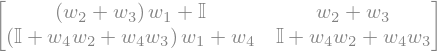

In [2]:
I2 = sp.Identity(2)
Z2 = sp.ZeroMatrix(2, 2)

w1 = sp.MatrixSymbol('w_1', 2, 2)
w2 = sp.MatrixSymbol('w_2', 2, 2)
w3 = sp.MatrixSymbol('w_3', 2, 2)
w4 = sp.MatrixSymbol('w_4', 2, 2)
Sigma = w2 + w3

M1 = sp.BlockMatrix([[I2, Z2], [w1, I2]])
M2 = sp.BlockMatrix([[I2, w2], [Z2, I2]])
M3 = sp.BlockMatrix([[I2, w3], [Z2, I2]])
M4 = sp.BlockMatrix([[I2, Z2], [w4, I2]])
J_abba = sp.block_collapse(M4 * M3 * M2 * M1)

A = I2 + w4 * Sigma
B = w1 + w4 + w4 * Sigma * w1
C = Sigma
D = I2 + Sigma * w1
J_abba_expected = sp.BlockMatrix([[D, C], [B, A]])

for actual_block, expected_block in zip(J_abba.blocks, J_abba_expected.blocks):
    assert sp.expand(actual_block) == sp.expand(expected_block)
display(J_abba)

## 2. Midpoint averaged physical Jacobian

The midpoint construction injects a physical perturbation diagonally with $E=(I,I)^T$ and averages the two final copies with $\Pi_{\mathrm{av}}=\tfrac12(I,I)$. Therefore

$$
D\Psi_{\mathrm{exp}}=\Pi_{\mathrm{av}}D\Phi_{\mathrm{ABBA}}E
=\frac12(A+B+C+D).
$$

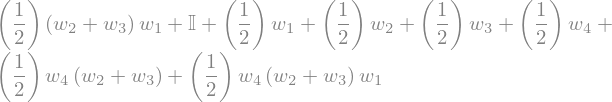

In [3]:
E = sp.BlockMatrix([[I2], [I2]])
Pi_average = sp.BlockMatrix([[I2 / 2, I2 / 2]])

J_midpoint_from_blocks = sp.block_collapse(Pi_average * J_abba * E)
J_midpoint = (
    I2
    + (w1 + Sigma + w4) / 2
    + (w4 * Sigma + Sigma * w1) / 2
    + w4 * Sigma * w1 / 2
)

assert sp.expand(J_midpoint_from_blocks - J_midpoint) == Z2
display(J_midpoint)

## 3. Semi-implicit physical Jacobian

The semi-implicit map adjusts the initial doubled perturbation so that the two final copies coincide. With $G=(-I,I)$ and $N=(-I,I)^T$, define

$$
K=GD\Phi_{\mathrm{ABBA}}N+2I,\qquad
L=GD\Phi_{\mathrm{ABBA}}E.
$$

For invertible $K$, implicit differentiation gives

$$
D\Psi_{\mathrm{semi}}=P-QK^{-1}L.
$$

Constraint Jacobian $K$:

Semi-implicit physical Jacobian:

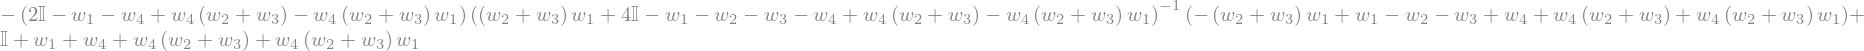

In [4]:
G = sp.BlockMatrix([[-I2, I2]])
N = sp.BlockMatrix([[-I2], [I2]])

K_from_blocks = sp.block_collapse(G * J_abba * N + 2 * I2)
L_from_blocks = sp.block_collapse(G * J_abba * E)

K = (
    4 * I2
    - (w1 + Sigma + w4)
    + (w4 * Sigma + Sigma * w1)
    - w4 * Sigma * w1
)
L = (
    w1 - Sigma + w4
    + w4 * Sigma - Sigma * w1
    + w4 * Sigma * w1
)
P = I2 + w1 + w4 + w4 * Sigma + w4 * Sigma * w1
Q = 2 * I2 - w1 - w4 + w4 * Sigma - w4 * Sigma * w1

assert sp.expand(K_from_blocks - K) == Z2
assert sp.expand(L_from_blocks - L) == Z2

J_semiimplicit = P - Q * sp.Inverse(K) * L
display(Markdown('Constraint Jacobian $K$:'))
display(K)
display(Markdown('Semi-implicit physical Jacobian:'))
display(J_semiimplicit)

## 4. Exact algebraic comparison

The midpoint Jacobian can be written with the same $P$ and $L$ used by the semi-implicit construction:

$$
D\Psi_{\mathrm{exp}}=P-\frac12L.
$$

Consequently, the exact difference is

$$
\boxed{
D\Psi_{\mathrm{exp}}-D\Psi_{\mathrm{semi}}
=\left(Q-\frac12K\right)K^{-1}L
}
$$

whenever $K$ is invertible. Thus the two maps differ only through the correction required to satisfy the final diagonal constraint.

Correction factor $R=Q-K/2$:

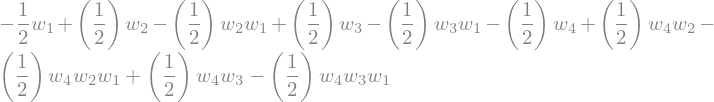

Factored Jacobian difference $RK^{-1}L$:

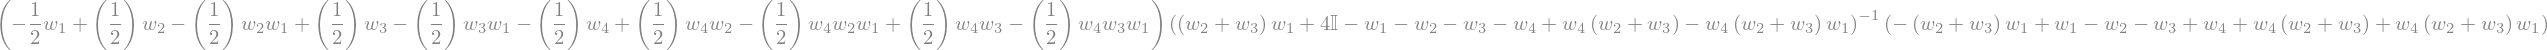

In [5]:
assert sp.expand(J_midpoint - (P - L / 2)) == Z2

R = sp.expand(Q - K / 2)
R_expected = (
    -w1 + Sigma - w4
    + w4 * Sigma - Sigma * w1
    - w4 * Sigma * w1
) / 2
assert sp.expand(R - R_expected) == Z2

difference_factored = R * sp.Inverse(K) * L
display(Markdown('Correction factor $R=Q-K/2$:'))
display(R)
display(Markdown('Factored Jacobian difference $RK^{-1}L$:'))
display(difference_factored)

The factorization separates three effects:

1. $L$ measures the mismatch produced at the final diagonal when the initial perturbation is duplicated without correction.
2. $K^{-1}$ converts that mismatch into the required implicit correction of the initial doubled state.
3. $R=Q-K/2$ measures how differently that correction is seen by the semi-implicit projection and by arithmetic averaging.

In particular, $L=0$ is a sufficient condition for the two physical Jacobians to coincide.

## 5. Exact evaluation for concrete $2\times2$ stage Jacobians

The helper below evaluates both formulas using exact SymPy matrices. It also retains $K$, $L$, $P$, $Q$, and $R$ so the factorization can be checked without assuming that the stage Jacobians commute.

In [6]:
def simplify_matrix(matrix):
    """Simplify and factor every entry of an exact SymPy matrix."""
    return sp.Matrix(matrix).applyfunc(lambda entry: sp.factor(sp.cancel(entry)))


def concrete_abba_jacobians(w1_value, w2_value, w3_value, w4_value):
    """Return explicit and semi-implicit physical Jacobians for small ABBA blocks."""
    identity = sp.eye(2)
    sigma = w2_value + w3_value

    a = identity + w4_value * sigma
    b = w1_value + w4_value + w4_value * sigma * w1_value
    c = sigma
    d = identity + sigma * w1_value

    k = (
        4 * identity
        - (w1_value + sigma + w4_value)
        + (w4_value * sigma + sigma * w1_value)
        - w4_value * sigma * w1_value
    )
    ell = (
        w1_value - sigma + w4_value
        + w4_value * sigma - sigma * w1_value
        + w4_value * sigma * w1_value
    )
    p = identity + w1_value + w4_value + w4_value * sigma + w4_value * sigma * w1_value
    q = 2 * identity - w1_value - w4_value + w4_value * sigma - w4_value * sigma * w1_value
    r = q - k / 2

    if sp.simplify(k.det()) == 0:
        raise ValueError('The semi-implicit constraint Jacobian K is singular.')

    midpoint = (a + b + c + d) / 2
    semiimplicit = p - q * k.inv() * ell
    difference = midpoint - semiimplicit

    assert simplify_matrix(difference - r * k.inv() * ell) == sp.zeros(2)
    return {
        'midpoint': simplify_matrix(midpoint),
        'semiimplicit': simplify_matrix(semiimplicit),
        'difference': simplify_matrix(difference),
        'K': simplify_matrix(k),
        'L': simplify_matrix(ell),
        'P': simplify_matrix(p),
        'Q': simplify_matrix(q),
        'R': simplify_matrix(r),
    }


Omega = sp.Matrix([[0, -1], [1, 0]])


def symplectic_defect(jacobian):
    """Return J.T*Omega*J-Omega in physical coordinates."""
    return simplify_matrix(jacobian.T * Omega * jacobian - Omega)

## 6. Linear oscillator: closed-form comparison

Consider the constant Hamiltonian vector field $f(z)=\Omega z$. Every stage has $w_i=(h/2)\Omega$, so the resulting formulas depend only on the physical step $h$.

Midpoint Jacobian:

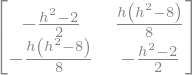

Semi-implicit Jacobian:

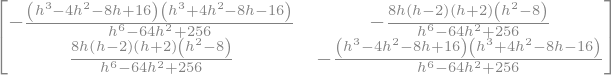

Exact difference:

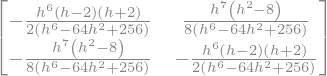

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Midpoint symplectic defect:

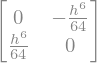

Semi-implicit symplectic defect:

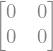

In [7]:
h = sp.symbols('h', real=True)
oscillator_stage = h * Omega / 2
oscillator = concrete_abba_jacobians(
    oscillator_stage,
    oscillator_stage,
    oscillator_stage,
    oscillator_stage,
)

J_mid_osc = oscillator['midpoint']
J_semi_osc = oscillator['semiimplicit']
J_difference_osc = oscillator['difference']

det_exp_osc = sp.factor(J_mid_osc.det())
det_semi_osc = sp.factor(J_semi_osc.det())
defect_exp_osc = symplectic_defect(J_mid_osc)
defect_semi_osc = symplectic_defect(J_semi_osc)

assert sp.expand(det_exp_osc - (1 + h**6 / 64)) == 0
assert det_semi_osc == 1
assert defect_exp_osc == sp.Matrix([[0, -h**6 / 64], [h**6 / 64, 0]])
assert defect_semi_osc == sp.zeros(2)

display(Markdown('Midpoint Jacobian:'))
display(J_mid_osc)
display(Markdown('Semi-implicit Jacobian:'))
display(J_semi_osc)
display(Markdown('Exact difference:'))
display(J_difference_osc)
display(Math(r'\det(D\Psi_{\mathrm{exp}})=' + sp.latex(det_exp_osc)))
display(Math(r'\det(D\Psi_{\mathrm{semi}})=' + sp.latex(det_semi_osc)))
display(Markdown('Midpoint symplectic defect:'))
display(defect_exp_osc)
display(Markdown('Semi-implicit symplectic defect:'))
display(defect_semi_osc)

### First order at which the Jacobians differ

The exact difference starts at order $h^6$. Its diagonal correction appears at order $h^6$, while its off-diagonal correction starts at order $h^7$.

Semi-implicit series through order $h^8$:

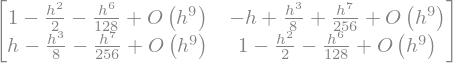

Difference through order $h^7$:

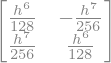

In [8]:
semi_series = J_semi_osc.applyfunc(lambda entry: sp.series(entry, h, 0, 9))
difference_through_h7 = J_difference_osc.applyfunc(
    lambda entry: sp.series(entry, h, 0, 8).removeO()
)
expected_difference_through_h7 = sp.Matrix(
    [[h**6 / 128, -h**7 / 256], [h**7 / 256, h**6 / 128]]
)

assert simplify_matrix(difference_through_h7 - expected_difference_through_h7) == sp.zeros(2)

display(Markdown('Semi-implicit series through order $h^8$:'))
display(semi_series)
display(Markdown('Difference through order $h^7$:'))
display(difference_through_h7)

## 7. Noncommuting Hamiltonian stage Jacobians

The oscillator example is highly symmetric because all stage matrices commute. The following exact rational example uses four different trace-free matrices, so it checks the comparison in a genuinely noncommuting case.

Midpoint Jacobian:

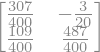

Semi-implicit Jacobian:

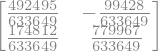

Exact difference:

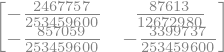

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Midpoint symplectic defect:

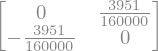

Semi-implicit symplectic defect:

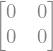

In [9]:
W1_value = sp.Matrix([[-1, -3], [2, 1]])
W2_value = sp.Matrix([[-2, -1], [-1, 2]])
W3_value = sp.Matrix([[1, -2], [3, -1]])
W4_value = sp.Matrix([[-3, 2], [1, 3]])
s_value = sp.Rational(1, 10)

noncommuting = concrete_abba_jacobians(
    s_value * W1_value,
    s_value * W2_value,
    s_value * W3_value,
    s_value * W4_value,
)

J_mid_noncommuting = noncommuting['midpoint']
J_semi_noncommuting = noncommuting['semiimplicit']
difference_noncommuting = noncommuting['difference']
det_exp_noncommuting = sp.factor(J_mid_noncommuting.det())
det_semi_noncommuting = sp.factor(J_semi_noncommuting.det())
defect_exp_noncommuting = symplectic_defect(J_mid_noncommuting)
defect_semi_noncommuting = symplectic_defect(J_semi_noncommuting)

assert W4_value * (W2_value + W3_value) != (W2_value + W3_value) * W4_value
assert det_exp_noncommuting != 1
assert det_semi_noncommuting == 1
assert defect_exp_noncommuting != sp.zeros(2)
assert defect_semi_noncommuting == sp.zeros(2)

display(Markdown('Midpoint Jacobian:'))
display(J_mid_noncommuting)
display(Markdown('Semi-implicit Jacobian:'))
display(J_semi_noncommuting)
display(Markdown('Exact difference:'))
display(difference_noncommuting)
display(Math(r'\det(D\Psi_{\mathrm{exp}})=' + sp.latex(det_exp_noncommuting)))
display(Math(r'\det(D\Psi_{\mathrm{semi}})=' + sp.latex(det_semi_noncommuting)))
display(Markdown('Midpoint symplectic defect:'))
display(defect_exp_noncommuting)
display(Markdown('Semi-implicit symplectic defect:'))
display(defect_semi_noncommuting)

## 8. Conclusions

- Both physical Jacobians start from the same doubled ABBA tangent map; only the physical closure changes.
- The midpoint map uses the arithmetic average $P-L/2$, whereas the semi-implicit map uses the constraint correction $P-QK^{-1}L$.
- Their exact difference is $(Q-K/2)K^{-1}L$.
- For the linear oscillator, both Jacobians agree through order $h^5$, but the midpoint determinant is $1+h^6/64$ while the semi-implicit determinant is exactly one.
- The noncommuting rational example confirms that the semi-implicit Jacobian remains symplectic while the midpoint averaged Jacobian has a nonzero symplectic defect.